In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [4]:
np.random.seed(1)

In [5]:
# Creating a dataset.

participants = 200

age = np.random.normal(loc=23, scale=3, size=participants).round()

gender = np.random.choice(
    ["Male", "Female"],
    size=participants
)

exercise_hours = np.random.normal(loc=4, scale=2, size=participants)

exercise_hours = np.clip(
    exercise_hours,
    0,
    None
)

stress_score = (70 - 4 * exercise_hours + np.random.normal(loc=0, scale=8, size=participants))

cognitive_score = (60 + 3 * exercise_hours - 0.2 * stress_score + np.random.normal(loc=0, scale= 5, size=participants))

df = pd.DataFrame({
    "participant_id": np.arange(1, participants + 1),
    "age": age,
    "gender": gender,
    "exercise_hours": exercise_hours,
    "stress_score": stress_score,
    "cognitive_score": cognitive_score
})

# Adding missing values.

for col in [
    "exercise_hours",
    "stress_score",
    "cognitive_score"
]:
    idx = np.random.choice(
        df.index,
        size=10,
        replace=False
    )
    df.loc[idx, col] = np.nan

In [6]:
# Saveing dataset.

df.to_csv(
    r"F:\doc-hub\education\psychology\projects\computational-cognitive-science-training\data\05-student-wellbeing-raw.csv",
    index=False
)

In [7]:
# Loading dataset.

df = pd.read_csv(r"F:\doc-hub\education\psychology\projects\computational-cognitive-science-training\data\05-student-wellbeing-raw.csv")

print(df.head())
print(df.describe())

   participant_id   age  gender  exercise_hours  stress_score  cognitive_score
0               1  28.0    Male        4.121500     65.201137              NaN
1               2  21.0    Male        4.422250     57.050784        54.898122
2               3  21.0  Female        4.033055     63.450426        61.660169
3               4  20.0  Female        4.354375     66.219252        62.956461
4               5  26.0    Male        1.767060     71.252473        54.807371
       participant_id        age  exercise_hours  stress_score  \
count      200.000000  200.00000      190.000000    190.000000   
mean       100.500000   23.33000        4.071163     54.310619   
std         57.879185    2.78566        2.013114     10.783333   
min          1.000000   16.00000        0.000000     23.718578   
25%         50.750000   21.75000        2.678657     46.335499   
50%        100.500000   23.00000        3.973181     54.921752   
75%        150.250000   25.00000        5.452576     61.155482  

In [8]:
# Cleaning data.

df_clean = df.dropna()

print(df.shape)
print(df_clean.shape)

(200, 6)
(171, 6)


##### Creating exploratory figures.

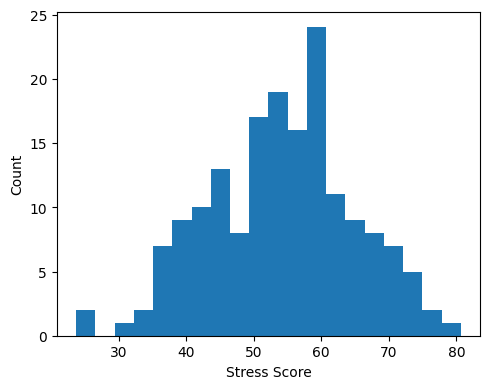

In [9]:
# Figure 1: sistribution of stress

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,4))

ax.hist(
    df_clean["stress_score"],
    bins=20
)

ax.set_xlabel("Stress Score")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

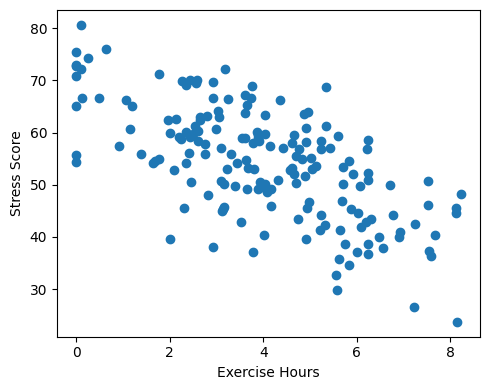

In [10]:
# Figure 2: exercise vs stress

fig, ax = plt.subplots(figsize=(5,4))

ax.scatter(
    df_clean["exercise_hours"],
    df_clean["stress_score"]
)

ax.set_xlabel("Exercise Hours")
ax.set_ylabel("Stress Score")

plt.tight_layout()
plt.show()

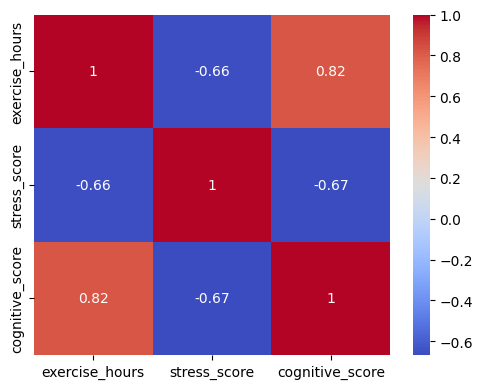

In [11]:
# Figure 3: correlation matrix

corr = df_clean[
    [
        "exercise_hours",
        "stress_score",
        "cognitive_score"
    ]
].corr()

fig, ax = plt.subplots(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    ax=ax
)

plt.tight_layout()
plt.show()

In [12]:
# Creating an inferential figure.

x = df_clean["exercise_hours"]
y = df_clean["stress_score"]

result = linregress(x, y)

print(result)

LinregressResult(slope=np.float64(-3.550580813600862), intercept=np.float64(68.30472641732257), rvalue=np.float64(-0.6587421421650462), pvalue=np.float64(1.208331224745264e-22), stderr=np.float64(0.3119402179616193), intercept_stderr=np.float64(1.3853878783684017))


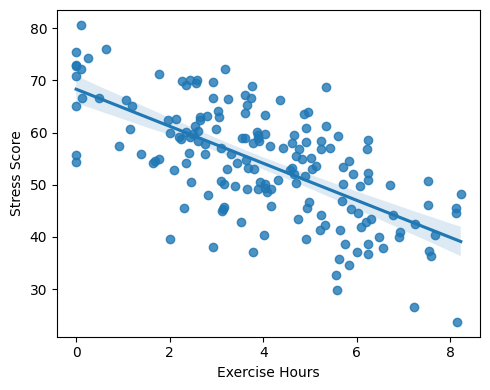

In [13]:
# Creating a regression plot.

fig, ax = plt.subplots(figsize=(5,4))

sns.regplot(
    data=df_clean,
    x="exercise_hours",
    y="stress_score",
    ax=ax
)

ax.set_xlabel("Exercise Hours")
ax.set_ylabel("Stress Score")

plt.tight_layout()
plt.show()

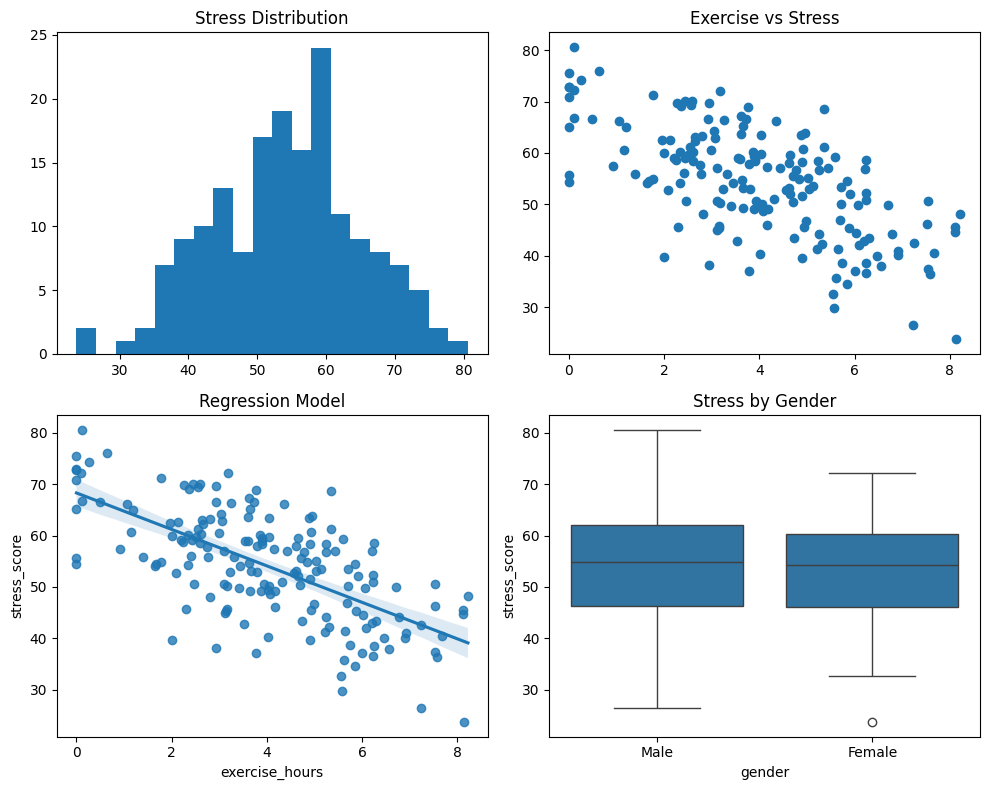

In [14]:
# Creating a summary figure.

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10,8)
)

# Distribution

axes[0,0].hist(
    df_clean["stress_score"],
    bins=20
)

axes[0,0].set_title("Stress Distribution")

# Scatter

axes[0,1].scatter(
    df_clean["exercise_hours"],
    df_clean["stress_score"]
)

axes[0,1].set_title(
    "Exercise vs Stress"
)

# Regression

sns.regplot(
    data=df_clean,
    x="exercise_hours",
    y="stress_score",
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Regression Model"
)

# Boxplot

sns.boxplot(
    data=df_clean,
    x="gender",
    y="stress_score",
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Stress by Gender"
)

plt.tight_layout()
plt.show()